# Correlation Analysis of Student Dropout

This notebook explores how academic performance, engagement, and enrollment variables relate to student dropout. It prepares the cleaned dataset, calculates Pearson correlations, visualizes the strongest relationships, fits a baseline linear regression model, evaluates error, and exports metrics for comparison across runs.

## 1. Setup

Install the libraries used for data handling, visualization, correlation testing, and modeling. This cell only needs to be run if the packages are not already available.


In [406]:
%pip install -q pandas seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Analysis workflow

The analysis follows five steps: load and inspect the data, prepare numeric variables, calculate correlations with dropout, test whether relationships are statistically significant, and evaluate a baseline prediction model.


## 2. Load the dataset

Read the cleaned CSV file into a pandas DataFrame and preview the first five rows. This confirms that the path is correct and gives a quick check of the column names, value ranges, and numeric formatting.


In [407]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../Data/dropout_clean_trimmed.csv"

df = pd.read_csv(file_path)
print(df[0:5])

   Dropout (1=Yes 0=No)  Entry Year  Performance Bucket  \
0                     0      2020.0                 3.0   
1                     0      2019.0                 2.0   
2                     0      2019.0                 3.0   
3                     0      2020.0                 0.0   
4                     0      2019.0                 2.0   

   Pass Rate Semester A (%)  Pass Rate Semester B (%)  \
0                     86.96                     73.91   
1                    100.00                     50.00   
2                    100.00                    100.00   
3                      0.00                      0.00   
4                    100.00                     55.00   

   Pass Rate Last Year (%)  Credits Passed Normal  Credits Passed Sem A  \
0                92.682927                   69.0                  30.0   
1                 0.000000                   31.5                  16.5   
2                76.190476                   61.5                  34.5   
3 

### Check row indexing

Verify whether every row in the DataFrame has a unique index value. A unique index makes it easier to trace rows later when splitting data or comparing predictions.


In [408]:
df.index.is_unique


True

## 3. Prepare variables

Inspect column types before analysis. Correlation and linear regression require numeric inputs, so this step helps identify columns that may need conversion, removal, or careful interpretation.


In [409]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9184 entries, 0 to 9183
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Dropout (1=Yes 0=No)          9184 non-null   int64  
 1   Entry Year                    9184 non-null   float64
 2   Performance Bucket            9184 non-null   float64
 3   Pass Rate Semester A (%)      9184 non-null   float64
 4   Pass Rate Semester B (%)      9184 non-null   float64
 5   Pass Rate Last Year (%)       9184 non-null   float64
 6   Credits Passed Normal         9184 non-null   float64
 7   Credits Passed Sem A          9184 non-null   float64
 8   Credits Passed Sem B          9184 non-null   float64
 9   Credits Enrolled Total        9184 non-null   float64
 10  Platform Days Logged (Total)  9184 non-null   float64
 11  Campus WiFi Days (Total)      9184 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 861.1 KB


### Columns with limited usable data

Some versions of the dataset contain sparse fields with many missing values. These columns should be reviewed before modeling because they can either produce weak correlations or force many rows to be removed if complete-case analysis is used.


Removing sparse columns prevents them from producing mostly missing correlations. Identifier columns and category-code columns also need caution because their numeric values may act as labels rather than true measured quantities.

### Select columns for correlation

Choose which columns to remove before correlation and modeling. In the current run, `columns_to_drop` is empty, so all available columns are kept. To compare different experiments, update this list and rerun the notebook.

In [410]:
columns_to_drop = []
df = df.drop(columns=columns_to_drop)
print(df)


      Dropout (1=Yes 0=No)  Entry Year  Performance Bucket  \
0                        0      2020.0                 3.0   
1                        0      2019.0                 2.0   
2                        0      2019.0                 3.0   
3                        0      2020.0                 0.0   
4                        0      2019.0                 2.0   
...                    ...         ...                 ...   
9179                     0      2020.0                 1.0   
9180                     0      2021.0                 3.0   
9181                     0      2019.0                 2.0   
9182                     0      2021.0                 3.0   
9183                     0      2020.0                 2.0   

      Pass Rate Semester A (%)  Pass Rate Semester B (%)  \
0                        86.96                     73.91   
1                       100.00                     50.00   
2                       100.00                    100.00   
3              

### Convert values to numeric data

Replace decimal commas with decimal points and convert every remaining column to a numeric type. This keeps correlation and regression from treating numeric-looking values as text.


In [411]:
df = df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric)

### Review missing values and prepared data

Review the prepared DataFrame before calculating correlations. Dropping rows with missing values can make the model cleaner, but it can also remove important dropout cases, so the choice should be documented for each experiment.


The full `dropna()` line is commented out because removing every row with any missing value may reduce the number of dropout students. Keep it commented when preserving the full dataset, or enable it when comparing a complete-case version.

In [412]:
#df = pd.DataFrame.dropna(df)

print(df)

      Dropout (1=Yes 0=No)  Entry Year  Performance Bucket  \
0                        0      2020.0                 3.0   
1                        0      2019.0                 2.0   
2                        0      2019.0                 3.0   
3                        0      2020.0                 0.0   
4                        0      2019.0                 2.0   
...                    ...         ...                 ...   
9179                     0      2020.0                 1.0   
9180                     0      2021.0                 3.0   
9181                     0      2019.0                 2.0   
9182                     0      2021.0                 3.0   
9183                     0      2020.0                 2.0   

      Pass Rate Semester A (%)  Pass Rate Semester B (%)  \
0                        86.96                     73.91   
1                       100.00                     50.00   
2                       100.00                    100.00   
3              

## 4. Calculate correlations

Calculate Pearson correlations for all numeric variables, then extract the correlations with the dropout indicator. Values near +1 mean higher feature values are associated with more dropout; values near -1 mean higher feature values are associated with less dropout; values near 0 suggest little linear relationship.


In [413]:
corr_matrix = df.corr()
corr_vector = df.corr()["Dropout (1=Yes 0=No)"]

print(corr_vector)


Dropout (1=Yes 0=No)            1.000000
Entry Year                      0.015016
Performance Bucket             -0.225935
Pass Rate Semester A (%)       -0.168230
Pass Rate Semester B (%)       -0.239598
Pass Rate Last Year (%)        -0.130684
Credits Passed Normal          -0.224758
Credits Passed Sem A           -0.132249
Credits Passed Sem B           -0.161991
Credits Enrolled Total         -0.053680
Platform Days Logged (Total)   -0.096320
Campus WiFi Days (Total)       -0.097127
Name: Dropout (1=Yes 0=No), dtype: float64


## 5. Visualize the full correlation matrix

Display all pairwise correlations in a heatmap. This helps identify groups of variables that move together, which matters because highly similar predictors can make model interpretation less clear.


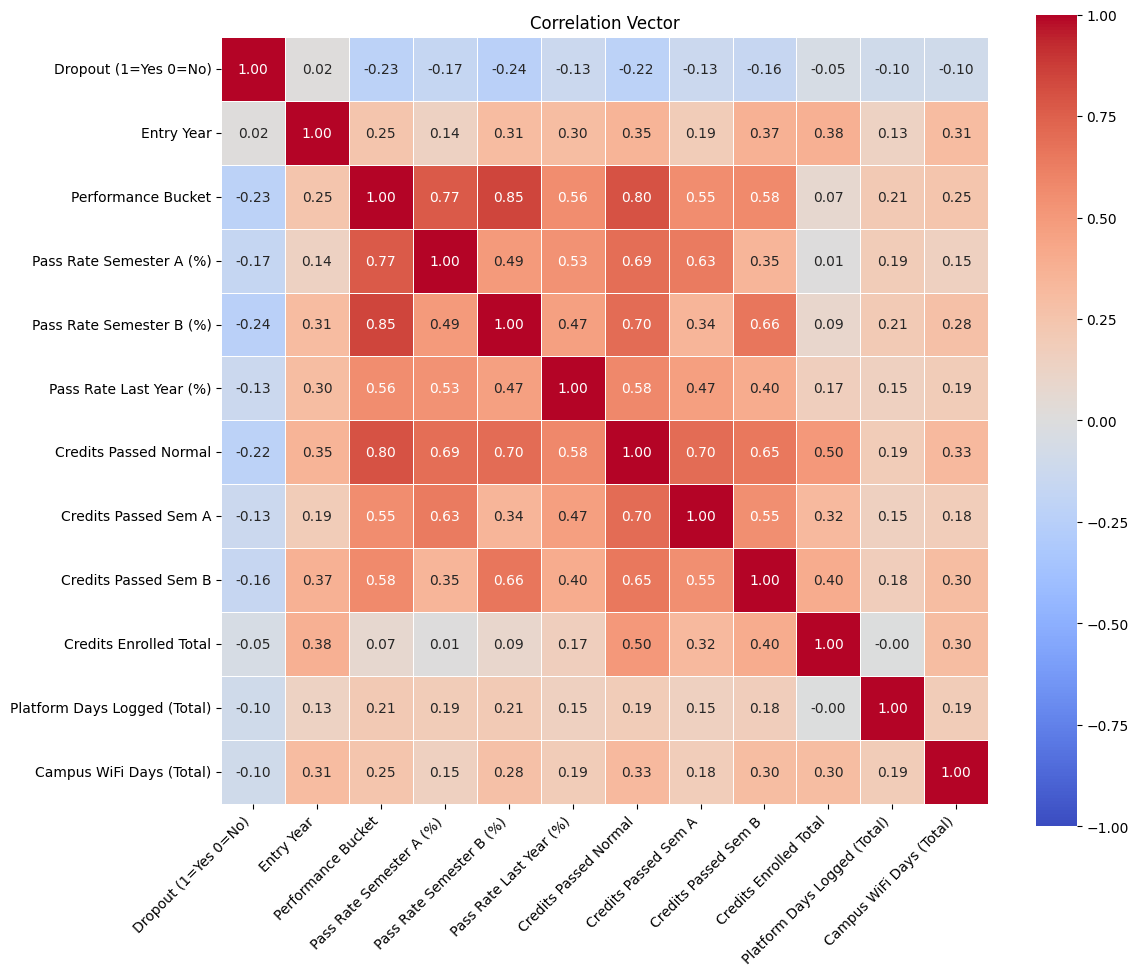

In [414]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Vector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Focus on correlations with dropout

Sort the dropout correlations by absolute value so the strongest positive or negative relationships appear first. This ranking is useful for feature selection, but it shows association rather than causation.


The target variable itself appears first with a correlation of 1.00 and should be ignored when interpreting predictors.

In [415]:
corr_vector = corr_vector.sort_values(key=abs, ascending=False)
reference_col = "Dropout (1=Yes 0=No) "
correlation_df = corr_vector.to_frame(name=f"Correlation with '{reference_col}'")
print(correlation_df)

                              Correlation with 'Dropout (1=Yes 0=No) '
Dropout (1=Yes 0=No)                                          1.000000
Pass Rate Semester B (%)                                     -0.239598
Performance Bucket                                           -0.225935
Credits Passed Normal                                        -0.224758
Pass Rate Semester A (%)                                     -0.168230
Credits Passed Sem B                                         -0.161991
Credits Passed Sem A                                         -0.132249
Pass Rate Last Year (%)                                      -0.130684
Campus WiFi Days (Total)                                     -0.097127
Platform Days Logged (Total)                                 -0.096320
Credits Enrolled Total                                       -0.053680
Entry Year                                                    0.015016


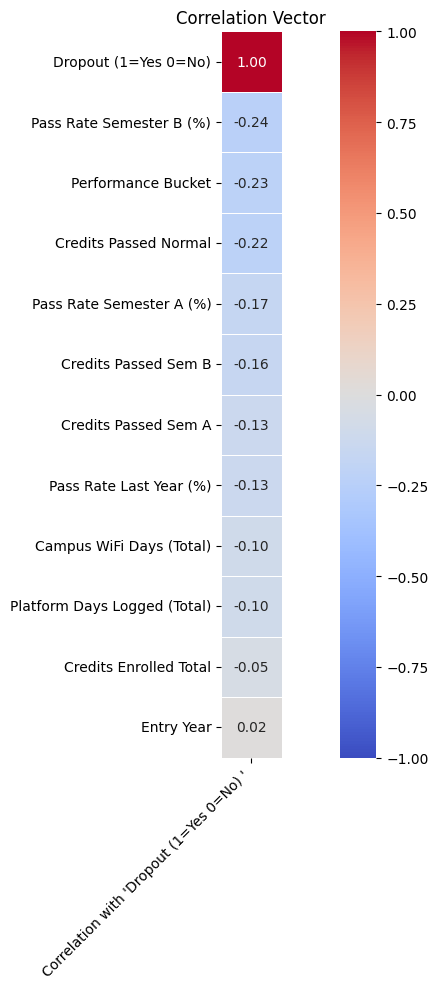

In [416]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Vector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Check statistical significance

Calculate a Pearson p-value for each relationship with dropout. Stars mark conventional significance levels: `*` p <= 0.05, `**` p <= 0.01, and `***` p <= 0.001. Statistical significance means the relationship is unlikely to be random in this sample, but it does not prove the effect is large or causal.

In [417]:
import numpy as np
from scipy.stats import pearsonr
pval = df.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*corr_matrix.shape)
p = pval.map(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))
(corr_matrix.round(2).astype(str)['Dropout (1=Yes 0=No)'] + p['Dropout (1=Yes 0=No)'])

Dropout (1=Yes 0=No)              1.0***
Entry Year                          0.02
Performance Bucket              -0.23***
Pass Rate Semester A (%)        -0.17***
Pass Rate Semester B (%)        -0.24***
Pass Rate Last Year (%)         -0.13***
Credits Passed Normal           -0.22***
Credits Passed Sem A            -0.13***
Credits Passed Sem B            -0.16***
Credits Enrolled Total          -0.05***
Platform Days Logged (Total)     -0.1***
Campus WiFi Days (Total)         -0.1***
Name: Dropout (1=Yes 0=No), dtype: object

## 7. Further feature visualizations

This section can be used to examine the strongest relationships in more detail with plots such as box plots, histograms, or grouped dropout rates.

## Train/test split

Split the data into training and testing sets so the model is evaluated on rows it did not use during fitting. This gives a more realistic estimate of how the model may perform on new student records.

In [418]:
train = df[:80]
test = df[20:]

## Linear Regression

In [419]:
from sklearn.linear_model import LinearRegression


In [420]:
# Create the baseline regression model.

model = LinearRegression()

Fit a baseline linear regression model. The model learns coefficients from the input features to estimate the dropout target. Since dropout is coded as 0/1, this is mainly useful as a simple baseline; logistic regression would be more appropriate for classification.

In [421]:
# Use dropout as the target because it is the outcome the project is trying to explain.
target = "Dropout (1=Yes 0=No)"
y = df[target]

In [422]:
columns_to_select = ["Performance Bucket", "Pass Rate Semester A (%)","Pass Rate Semester B (%)" , "Credits Passed Normal"]


In [423]:
from sklearn import model_selection
# Use the remaining columns as predictors, excluding the answer column.
X = df.drop(columns=[target])

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y)

In [424]:
model.fit(X_train, y_train)

LinearRegression()

In [425]:
r_sq = model.score(X_test,y_test)
print(r_sq)

0.09407055577372114


## Model error

Use the fitted model to predict the test set, then calculate mean absolute error. MAE measures the average size of the prediction mistake in the same units as the target. Since dropout is coded as 0/1, lower MAE means the predictions are closer to the true dropout labels.

### Calculate MAE

In [426]:
y_pred = model.predict(X_test)

In [427]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.07177245261305747


### Export metrics

Save the current run's metrics with a timestamp. Keeping each run in the results folder makes it easier to compare experiments such as all features vs. selected features, trimmed vs. untrimmed data, or with vs. without missing-value removal.

In [428]:
from pathlib import Path
from datetime import datetime

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

metrics_df = pd.DataFrame({
    "date_time": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    "metric": ["r_squared"],
    "value": [r_sq],
    "MAE:": [mae],
})

metrics_df.to_csv(results_dir / "linear_regression_metrics.csv", index=False)

print("Saved linear_regression_metrics.csv")

Saved linear_regression_metrics.csv
